# Design Patterns

<p style="font-size:1.25em; color:#555; margin-top:0;">Two tracks: the 23 Gang of Four patterns, then the architectures they live in</p>

<p style="color:#777;">Every pattern as a class diagram, a runnable Python implementation, a sequence diagram traced from the real calls, and a lab where you drive it yourself.</p>

## Who this is for

You can write Python classes and functions and you have felt code get tangled. That is enough. No prior exposure to patterns or UML is assumed;
the diagrams are introduced as you meet them and the notation is deliberately minimal.

By the end you will be able to:

* recognise the 23 classic patterns by the problem they solve, not by their names, and implement any of them from memory;
* read and draw class and sequence diagrams well enough to discuss a design with someone else;
* say which patterns Python already gives you for free, and when a plain function beats a class hierarchy;
* explain monoliths, modular monoliths, layered and hexagonal designs, microservices and event-driven systems, with their trade-offs, and choose between them for a given team.

## Track 1: the Gang of Four patterns (`gof/`)

| # | Notebook | Patterns |
|---|----------|----------|
| 1 | [Creational Patterns](gof/01_Creational.ipynb) | Singleton, Factory Method, Abstract Factory, Builder, Prototype |
| 2 | [Structural Patterns, Part 1](gof/02_Structural_Part_1.ipynb) | Adapter, Bridge, Composite, Decorator |
| 3 | [Structural Patterns, Part 2](gof/03_Structural_Part_2.ipynb) | Facade, Flyweight, Proxy |
| 4 | [Behavioral Patterns, Part 1](gof/04_Behavioral_Part_1.ipynb) | Chain of Responsibility, Command, Iterator, Mediator |
| 5 | [Behavioral Patterns, Part 2](gof/05_Behavioral_Part_2.ipynb) | Observer, State, Strategy, Memento |
| 6 | [Behavioral Patterns, Part 3](gof/06_Behavioral_Part_3.ipynb) | Template Method, Visitor, Interpreter |
| 7 | [Patterns in Python](gof/07_Patterns_in_Python.ipynb) | What Python gives you for free, anti-patterns, a capstone that combines four patterns |

## Track 2: architecture patterns (`architecture/`)

| # | Notebook | What you learn |
|---|----------|----------------|
| 1 | [Monolith and Modular Monolith](architecture/01_Monolith_and_Modular_Monolith.ipynb) | One deployable, the big ball of mud, enforcing module boundaries, blast radius |
| 2 | [Layered, Hexagonal and MVC](architecture/02_Layered_Hexagonal_and_MVC.ipynb) | Dependency direction, ports and adapters, testing the core without a database, MVC as Observer |
| 3 | [Microservices](architecture/03_Microservices.ipynb) | Services with their own data, availability maths, latency simulator, timeouts, retries, circuit breakers |
| 4 | [Event-Driven and CQRS](architecture/04_Event_Driven_and_CQRS.ipynb) | Publish/subscribe, eventual consistency, CQRS read models, sagas with compensation |
| 5 | [Choosing an Architecture](architecture/05_Choosing_an_Architecture.ipynb) | Trade-off table, the migration path, strangler fig, Conway's law, an architecture picker |

**Suggested path:** track 1 in order, then track 2. The architecture notebooks reuse Observer, Facade, Proxy and Command, so they read better after the first track.

## How each pattern is presented

Every pattern section has the same six parts, so you always know where you are:

1. **Problem.** The situation that hurts, in one paragraph.
2. **Structure.** A class diagram of the roles involved.
3. **Code.** A complete Python implementation, short enough to read in one screen.
4. **Trace.** Client code run under a tracer that records the real method calls and draws them as a sequence diagram. What you see is what ran.
5. **When to use it, and when not.** Including the Python shortcut where one exists.
6. **What to notice.** The one detail in the code or diagram that makes the pattern work.

Each module ends with a lab, exercises with solutions behind a *Solutions* toggle, a checkpoint quiz and key takeaways.

## Environment check

Run this first. It confirms the `design_patterns` kernel has the libraries and that the `dplab` helper package imports from any folder.

Python      3.13.11
Interpreter /Users/indranandjha/Developer/personal/design_patterns/.venv/bin/python3
matplotlib  3.11.1
ipywidgets  8.1.9
dplab imported from dplab/__init__.py


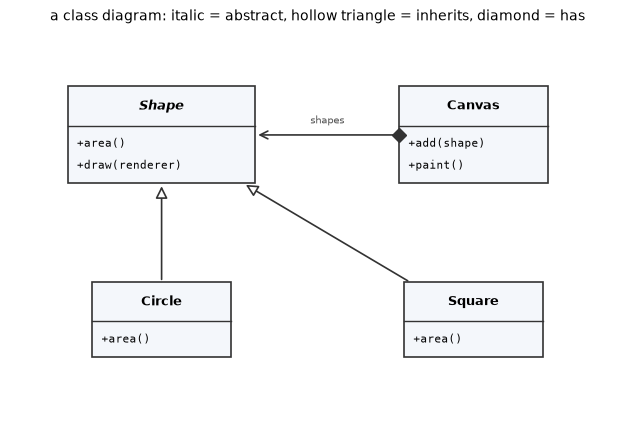

In [1]:
import sys
import matplotlib, ipywidgets

print(f"Python      {sys.version.split()[0]}")
print(f"Interpreter {sys.executable}")
for name, mod in [("matplotlib", matplotlib), ("ipywidgets", ipywidgets)]:
    print(f"{name:<12}{mod.__version__}")

import dplab
from dplab import class_diagram
print("dplab imported from", dplab.__file__.rsplit("/src/", 1)[-1])

class_diagram(
    {"Shape": ["+area()", "+draw(renderer)"], "Circle": ["+area()"], "Square": ["+area()"], "Canvas": ["+add(shape)", "+paint()"]},
    [("Circle", "Shape", "inherits"), ("Square", "Shape", "inherits"), ("Canvas", "Shape", "has", "shapes")],
    abstract={"Shape"}, title="a class diagram: italic = abstract, hollow triangle = inherits, diamond = has")

## Your toolkit

| Helper | What it does |
|--------|--------------|
| `class_diagram(classes, relations)` | Boxes and arrows. Relation kinds: `inherits` (solid, hollow triangle), `implements` (dashed, hollow triangle), `has` (diamond at the owner), `uses` (dashed arrow), `refers` (solid arrow). |
| `@traced` and `with trace() as t:` | Decorate classes, run client code inside the block, then `t.diagram()` draws the sequence diagram of the calls that actually happened. |
| `sequence_diagram`, `state_diagram`, `tree_diagram`, `component_diagram` | Hand-drawn versions when you want to sketch a design before coding it. |
| `quiz(n)` | Checkpoint quizzes: 1 to 7 for the Gang of Four track, `'arch1'` to `'arch5'` for architecture. |

The tracer is the tool you will use most. Here it is on three tiny classes.

Client -> Order(o-17): new Order('o-17', Payment, Warehouse)
Client -> Order(o-17): checkout('lamp', 25)
Order(o-17) -> Warehouse: reserve('lamp')
Order(o-17) -> Payment: charge(25)


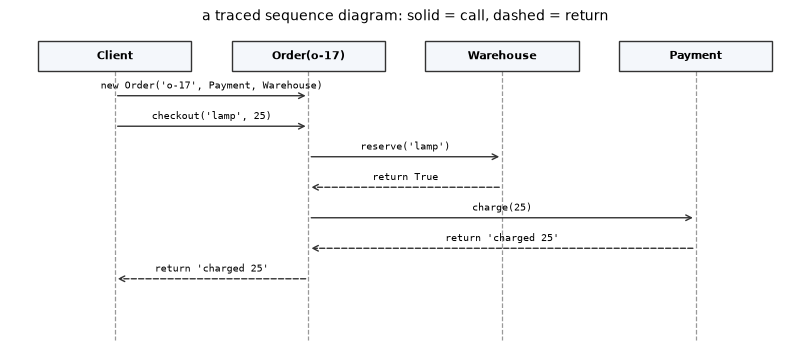

In [2]:
from dplab import traced, trace

@traced
class Payment:
    def charge(self, amount):
        return f"charged {amount}"

@traced
class Warehouse:
    def reserve(self, item):
        return True

@traced
class Order:
    def __init__(self, name, payment, warehouse):
        self.name, self.payment, self.warehouse = name, payment, warehouse

    def checkout(self, item, amount):
        self.warehouse.reserve(item)
        return self.payment.charge(amount)

with trace(returns=True) as t:                       # everything inside the block is recorded
    order = Order("o-17", Payment(), Warehouse())
    order.checkout("lamp", 25)

print(t.text())
t.diagram(title="a traced sequence diagram: solid = call, dashed = return")

## The labs

| Lab | Where | What you do |
|-----|-------|-------------|
| Pattern Picker | here, and GoF 7 | Describe the pain, get the pattern and where it is taught. |
| Builder Lab | GoF 1 | Assemble a product step by step; switch builders to change the representation. |
| Decorator Lab | GoF 2 | Stack wrappers in any order and watch the result and the nesting. |
| Flyweight Lab | GoF 3 | Measure the memory of a forest with and without shared tree types. |
| Chain and Command Labs | GoF 4 | Route a request through approvers; edit text with undo and redo stacks. |
| Observer and State Machine Labs | GoF 5 | Attach observers and trace notifications; fire events at a state machine. |
| Interpreter Lab | GoF 6 | Type an expression, see its tree, evaluate it, print it with a visitor. |
| Latency Lab | Architecture 3 | Chain services over a simulated network and watch tail latency and availability. |
| Event Lab | Architecture 4 | Publish events, tick the consumer, watch the read model catch up. |
| Architecture Picker | Architecture 5 | Five questions about your team, a ranked recommendation with reasons. |

In [3]:
from dplab import pattern_picker

pattern_picker()

Pattern Picker (static preview). Run this cell in JupyterLab for the interactive version.


## Glossary

* **Client**: the code that uses a pattern's objects; the participant the sequence diagrams start from.
* **Abstract class / interface**: a class that names methods without implementing them all; in Python usually an `abc.ABC` or a `typing.Protocol`, or just a convention.
* **Composition**: an object holds another object and delegates to it. The alternative to inheritance that most patterns prefer.
* **Coupling**: how much one part must know about another. Patterns exist to reduce it in specific places.
* **Deployable**: a unit you can build, test and release on its own: a monolith, or one service.
* **Double dispatch**: choosing behaviour based on the runtime types of two objects; the trick behind Visitor.
* **Idempotent**: safe to repeat; essential for retries in distributed systems.
* **Invariant**: a rule that always holds (a state machine only changes state through transitions).
* **Port / adapter**: an interface the core defines, and a concrete implementation of it at the edge of the system.
* **Read model / write model**: in CQRS, the shape of data optimised for queries versus for updates.

[Course Index](00_Start_Here.ipynb)  |  [Start track 1: GoF 1: Creational Patterns](gof/01_Creational.ipynb)  |  [Start track 2: Architecture 1: Monolith and Modular Monolith](architecture/01_Monolith_and_Modular_Monolith.ipynb)